---
date: "2026-06-19"
date-modified: last-modified
format:
  html:
    toc: true
---

# Expected Value, Linearity, and LOTUS

# Core Principles of Expectation

## 1. The Concept of Expected Value

The **expected value** (or mean) of a [random variable](random-variables.ipynb) is a single-number summary representing the theoretical "center of mass" or the long-run arithmetic average of the distribution. 

For a discrete random variable $X$ with distinct possible values $x_1, x_2, \dots$, the expected value $E[X]$ is defined as the weighted average of its possible values, where the weights are the probabilities of those values occurring:

$$E[X] = \sum_{x} x P(X = x)$$

**Important Caveats:**

* The sum is taken over the entire support of $X$. If the infinite series diverges, the expected value is mathematically undefined.
* $E[X]$ is a constant scalar value. It is **not** a random variable itself.
* $X$ does not necessarily ever equal $E[X]$. (For example, the expected value of a standard 6-sided die roll is 3.5, which is not a face on the die).

---

## 2. Linearity of Expectation

Linearity is arguably the most powerful and versatile property of expected values. It states that the expected value of a linear combination of random variables is simply the linear combination of their individual expected values.

For any random variables $X, Y$ and any scalar constants $a, b$:
$$E[aX + bY] = aE[X] + bE[Y]$$

**Crucial Insight:** Linearity holds **regardless of whether the random variables are independent or dependent**. Even if $Y$ is completely intertwined with the outcome of $X$, you can still safely add their expected values.

### Proof of Linearity (Discrete Case)
We can prove this using the joint Probability Mass Function (PMF), $P(X=x, Y=y)$. By the definition of expectation for a function of two variables:
$$E[X + Y] = \sum_x \sum_y (x + y) P(X=x, Y=y)$$

Distribute the sum:
$$E[X + Y] = \sum_x \sum_y x P(X=x, Y=y) + \sum_x \sum_y y P(X=x, Y=y)$$

Pull out the variables that do not depend on the inner sum:
$$E[X + Y] = \sum_x x \left( \sum_y P(X=x, Y=y) \right) + \sum_y y \left( \sum_x P(X=x, Y=y) \right)$$

By the law of marginal probability, summing the joint PMF over all $y$ gives the marginal PMF of $X$, and vice versa:
$$E[X + Y] = \sum_x x P(X=x) + \sum_y y P(Y=y)$$

This perfectly collapses back to the definition of the individual expected values:
$$E[X + Y] = E[X] + E[Y] \quad \blacksquare$$

---

### Monotonicity of Expectation

A direct consequence of linearity is monotonicity. If a random variable $X$ is always greater than or equal to $Y$ (meaning $P(X \ge Y) = 1$), then their expected values strictly reflect this relationship:
$$E[X] \ge E[Y]$$

### Proof of Monotonicity
Assume $X \ge Y$ with probability 1. We can define a new random variable $Z = X - Y$. 

Because $X \ge Y$, we know that $Z$ is a strictly non-negative random variable ($Z \ge 0$). 
Since the expected value of $Z$ is calculated as $E[Z] = \sum_z z P(Z=z)$, and both $z$ and $P(Z=z)$ are always non-negative, it must be true that:
$$E[Z] \ge 0$$

Now, we apply the Linearity of Expectation:
$$E[Z] = E[X - Y] = E[X] - E[Y]$$

Substituting this back into our inequality:
$$E[X] - E[Y] \ge 0$$
$$E[X] \ge E[Y] \quad \blacksquare$$

---

## 4. Expectation of a Function of a Random Variable

Often, we need the expected value of a transformed random variable, $g(X)$ (e.g., $X^2$ or $e^X$). 
A common fallacy is to assume $E[g(X)] = g(E[X])$. **This is almost always false unless $g$ is a strictly linear function.**

Instead, we use the **Law of the Unconscious Statistician (LOTUS)**. LOTUS dictates that we can find the expectation of $g(X)$ using the original probability mass function of $X$, without ever needing to find the complex PMF of the new variable $Y = g(X)$:

$$E[g(X)] = \sum_{x} g(x) P(X = x)$$

### The St. Petersburg Paradox
The danger of confusing $E[g(X)]$ with $g(E[X])$ is famously highlighted by the St. Petersburg Paradox. 
Suppose a casino offers a game: a fair coin is flipped until it lands Heads. If it takes $N$ flips, your payout is $2^N$ dollars. 

What is the expected payout $E[2^N]$? Using LOTUS:
$$E[2^N] = \sum_{n=1}^\infty 2^n P(N = n) = \sum_{n=1}^\infty 2^n \left(\frac{1}{2^n}\right) = \sum_{n=1}^\infty 1 = \infty$$

The expected payout is mathematically infinite. However, the expected length of the game $E[N]$ is only $2$ flips. If you mistakenly assumed $E[2^N] = 2^{E[N]}$, you would calculate an expected payout of $\$4$, which vastly misrepresents the infinite mathematical expectation driven by the rare, enormous payouts in the distribution's tail.

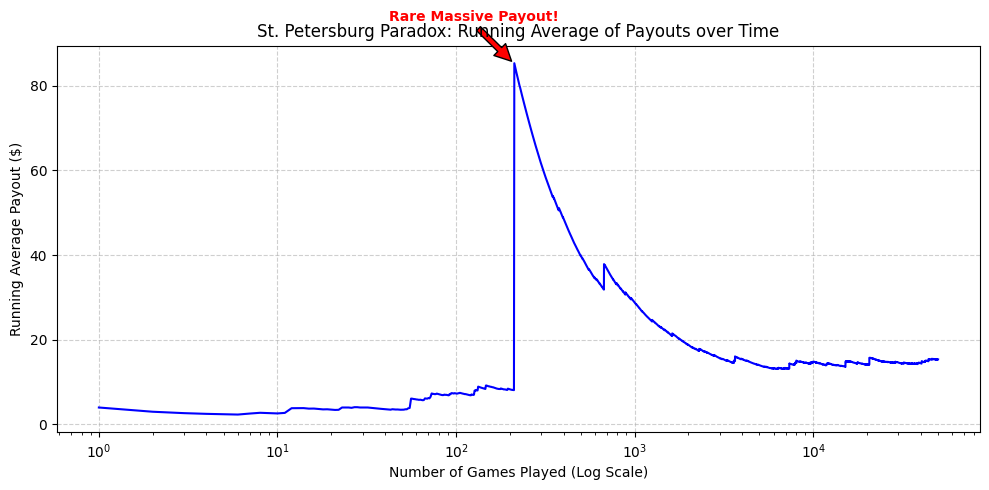

In [1]:
#| label: fig-st-petersburg
#| fig-cap: "Monte Carlo Simulation of the St. Petersburg Paradox. Notice how the running average never truly stabilizes; rare massive payouts continually pull the mean upward, reflecting the infinite theoretical expectation."

import numpy as np
import matplotlib.pyplot as plt

def simulate_st_petersburg(trials):
    """Simulate the St. Petersburg game and return the sequence of payouts."""
    payouts = np.zeros(trials)
    for i in range(trials):
        flips = 1
        while np.random.rand() < 0.5:
            flips += 1
        payouts[i] = 2**flips
    return payouts

# Run simulation
trials = 50000
payouts = simulate_st_petersburg(trials)
running_average = np.cumsum(payouts) / np.arange(1, trials + 1)

# Plotting
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(1, trials + 1), running_average, color='blue', linewidth=1.5)
ax.set_xscale('log')
ax.set_xlabel('Number of Games Played (Log Scale)')
ax.set_ylabel('Running Average Payout ($)')
ax.set_title('St. Petersburg Paradox: Running Average of Payouts over Time')
ax.grid(True, linestyle='--', alpha=0.6)

# Annotate a massive jump if one occurs
max_jump_idx = np.argmax(np.diff(running_average))
if max_jump_idx > 0:
    ax.annotate('Rare Massive Payout!', 
                xy=(max_jump_idx, running_average[max_jump_idx+1]), 
                xytext=(max_jump_idx*0.2, running_average[max_jump_idx+1] + 10),
                arrowprops=dict(facecolor='red', shrink=0.05),
                color='red', fontweight='bold')

plt.tight_layout()
plt.show()